In [27]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from sympy import Matrix, nsimplify, latex
from IPython.display import display

    The aim of this notebook is to understand the construction of different lattices using the software package KWANT. We will start with the basic 1D monoatomic chain, diatomic chain and then we would construct some 2D lattices like square lattice, square lattice with two atoms per unit cells and other non-trivial lattices. 

## 1D monoatomic chain

$$
H
=
\sum_i \epsilon_i |i\rangle\langle i|
+
\sum_i
\left(
t|i\rangle\langle i+1|
+
t^*|i+1\rangle\langle i|
\right),
$$

with

$$
\epsilon_i=0,
\qquad
t=-1.
$$

In [2]:
lat_mono1D = kwant.lattice.chain(a=1, norbs=1) # construct the object lat
syst_mono1D = kwant.Builder()

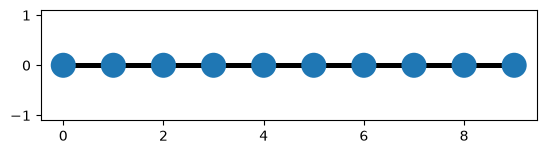

In [6]:
Nx_mono1D = 10

# Add sites
for i in range(Nx_mono1D):
    syst_mono1D[lat_mono1D(i)] = 0

# Add nearest-neighbor hoppings
syst_mono1D[lat_mono1D.neighbors()] = -1

kwant.plot(syst_mono1D);

In [33]:
## Finalize the system and get the hamiltonian

fsyst_mono1D = syst_mono1D.finalized()
H_mono1D = fsyst_mono1D.hamiltonian_submatrix()

H_mono1D = Matrix(H_mono1D).applyfunc(nsimplify)
H_mono1D

Matrix([
[ 0, -1,  0,  0,  0,  0,  0,  0,  0,  0],
[-1,  0, -1,  0,  0,  0,  0,  0,  0,  0],
[ 0, -1,  0, -1,  0,  0,  0,  0,  0,  0],
[ 0,  0, -1,  0, -1,  0,  0,  0,  0,  0],
[ 0,  0,  0, -1,  0, -1,  0,  0,  0,  0],
[ 0,  0,  0,  0, -1,  0, -1,  0,  0,  0],
[ 0,  0,  0,  0,  0, -1,  0, -1,  0,  0],
[ 0,  0,  0,  0,  0,  0, -1,  0, -1,  0],
[ 0,  0,  0,  0,  0,  0,  0, -1,  0, -1],
[ 0,  0,  0,  0,  0,  0,  0,  0, -1,  0]])

In [34]:
# print(latex(H_mono1D))

## 1D Diatomic chain


$$A = 0.0, \quad B = 0.5$$

$$
H=
\sum_n
\left[
\epsilon_A\,|A_n\rangle\langle A_n|
+
\epsilon_B\,|B_n\rangle\langle B_n|
\right]
+
\sum_n
\left[
t_1 |A_n\rangle\langle B_n|
+
t_2 |A_{n+1}\rangle\langle B_n|
+\text{h.c.}
\right]
$$

For a finite chain, if the basis is ordered as

$$
\left(
|A_0\rangle,
|B_0\rangle,
|A_1\rangle,
|B_1\rangle,
|A_2\rangle,
|B_2\rangle,
\dots
\right),
$$

the Hamiltonian matrix is

$$
H=
\begin{pmatrix}
\epsilon_A & t_1 & 0 & 0 & 0 & \cdots\\
t_1^* & \epsilon_B & t_2 & 0 & 0 & \cdots\\
0 & t_2^* & \epsilon_A & t_1 & 0 & \cdots\\
0 & 0 & t_1^* & \epsilon_B & t_2 & \cdots\\
0 & 0 & 0 & t_2^* & \epsilon_A & \cdots\\
\vdots & \vdots & \vdots & \vdots & \vdots & \ddots
\end{pmatrix}.
$$

In [9]:
a = 1

lat_dia1D = kwant.lattice.general(
    [(a,)],                    # primitive vector
    [(0,), (a/2,)],            # A and B positions inside unit cell
    norbs=1
)

A, B = lat_dia1D.sublattices

syst_dia1D = kwant.Builder()

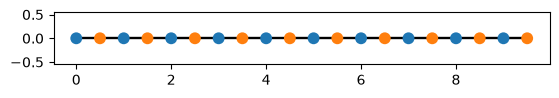

In [16]:
Nx_dia1D = 10
eps_A = 0
eps_B = 0

t1 = -1
t2 = -1

for i in range(Nx_dia1D):
    syst_dia1D[A(i)] = eps_A
    syst_dia1D[B(i)] = eps_B

# Intracell hopping: A_i <-> B_i
for i in range(Nx_dia1D):
    syst_dia1D[A(i), B(i)] = t1

# Intercell hopping: B_i <-> A_{i+1}
for i in range(Nx_dia1D - 1):
    syst_dia1D[B(i), A(i + 1)] = t2

kwant.plot(syst_dia1D);

In [24]:
## Finalize the system and get the hamiltonian

fsyst_dia1D = syst_dia1D.finalized()
H_dia1D = fsyst_dia1D.hamiltonian_submatrix()

Matrix(H_dia1D).applyfunc(nsimplify)

Matrix([
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0],
[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1],
[-1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
[ 0, -1, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
[ 0,  0

## 2D Square Lattice

$$H = \sum_i \epsilon_i c_i^\dagger c_i -t \sum_{\langle i,j\rangle} c_i^\dagger c_j + h.c. $$

In [37]:
lat_sq_mono = kwant.lattice.square(a=1, norbs=1)
syst_sq_mono = kwant.Builder()

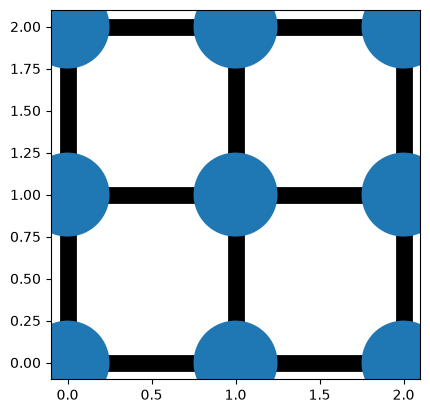

In [40]:
Nx = 3
Ny = 3
t = 1.0

for i in range(Nx):
    for j in range(Ny):
        syst_sq_mono[lat(i, j)] = 0

syst_sq_mono[lat_sq_mono.neighbors()] = -t
kwant.plot(syst_sq_mono);

In [44]:
fsyst_sq_mono = syst_sq_mono.finalized()

H_sq_mono = fsyst_sq_mono.hamiltonian_submatrix()
H_sq_mono = Matrix(H_sq_mono).applyfunc(nsimplify)
H_sq_mono

Matrix([
[ 0, -1,  0, -1,  0,  0,  0,  0,  0],
[-1,  0, -1,  0, -1,  0,  0,  0,  0],
[ 0, -1,  0,  0,  0, -1,  0,  0,  0],
[-1,  0,  0,  0, -1,  0, -1,  0,  0],
[ 0, -1,  0, -1,  0, -1,  0, -1,  0],
[ 0,  0, -1,  0, -1,  0,  0,  0, -1],
[ 0,  0,  0, -1,  0,  0,  0, -1,  0],
[ 0,  0,  0,  0, -1,  0, -1,  0, -1],
[ 0,  0,  0,  0,  0, -1,  0, -1,  0]])

## 2D Square Diatomic

Now we construct a square lattice with two atom unit cell.

$$A = (0, 0), \quad B = (0.5, 0.5)$$

and, primitive lattice vectors, 
$$a_1 = (1, 0) \text{ and } a_2=(0,1)$$

In [47]:
lat_sq_dia = kwant.lattice.general(
    [(1, 0), (0, 1)],             # primitive vectors
    [(0, 0), (0.5, 0.5)],         # positions of atoms A and B
    norbs=1
)

A, B = lat_sq_dia.sublattices
syst_sq_dia = kwant.Builder()

In [48]:
print(A(0, 0).pos)
print(B(0, 0).pos)

[0.0 0.0]
[0.5 0.5]


```
B(i-1,j)       B(i,j)
       \       /
        \ t2  / t1
         \   /
          A(i,j)
         /   \
        / t4  \ t3
       /       \
B(i-1,j-1)    B(i,j-1)
```

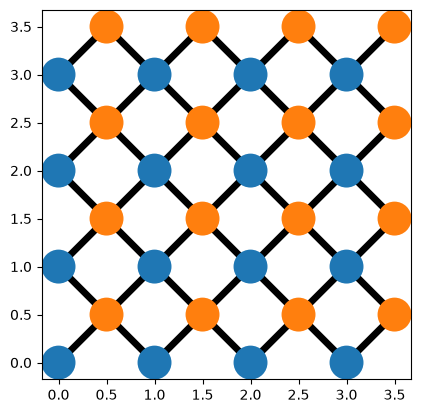

In [57]:
Nx = 4
Ny = 4

t1 = 1.0
t2 = 1.0
t3 = 1.0
t4 = 1.0

## Onsite
for i in range(Nx):
    for j in range(Ny):
        syst_sq_dia[A(i, j)] = 0
        syst_sq_dia[B(i, j)] = 0

## Hopping

for i in range(Nx):
    for j in range(Ny):

        # same unit cell
        syst_sq_dia[A(i, j), B(i, j)] = t1

        # Neighboring unit cell in -x direction
        if i > 0:
            ## This is because if i=0 then B(i-1, j) = B(-1,j) which is not in the sample lattice
            syst_sq_dia[A(i, j), B(i-1, j)] = t2

        # Neighboring unit cell in -y direction
        if j > 0:
            syst_sq_dia[A(i, j), B(i, j - 1)] = t3

        # Neighboring unit cell in -x,-y direction
        if i > 0 and j > 0:
            syst_sq_dia[A(i, j), B(i - 1, j - 1)] = t4

kwant.plot(syst_sq_dia);

In [58]:
fsyst_sq_dia = syst_sq_dia.finalized()

H_sq_dia = fsyst_sq_dia.hamiltonian_submatrix()
H_sq_dia = Matrix(H_sq_dia).applyfunc(nsimplify)
H_sq_dia

Matrix([
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0

In [54]:
# Nx = 4
# Ny = 4
# t = -1

# for i in range(Nx):
#     for j in range(Ny):
#         syst_sq_dia[A(i, j)] = 0
#         syst_sq_dia[B(i, j)] = 0

# ## assigns the same hopping to every geometrically nearest-neighbor bond.
# # syst_sq_dia[lat_sq_dia.neighbors()] = t

# kwant.plot(syst_sq_dia);